<a href="https://colab.research.google.com/github/Taniya-roy20/ML-PROJECT/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()   # a button will appear -> choose apple.csv from your PC

CSV_PATH = list(uploaded.keys())[0]
print("Loaded file:", CSV_PATH)

Saving FAOSTAT_data_en_8-19-2026.csv to FAOSTAT_data_en_8-19-2026.csv
Loaded file: FAOSTAT_data_en_8-19-2026.csv


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_data(path):
    df = pd.read_csv(path)

    year_col = df.columns[9]
    yield_col = df.columns[11]

    data = df[[year_col, yield_col]].copy()
    data.columns = ["year", "yield"]

    data["year"] = pd.to_numeric(data["year"], errors="coerce")
    data["yield"] = pd.to_numeric(data["yield"], errors="coerce")
    data = data.dropna()

    data["year"] = data["year"].astype(int)

    return data


def train_linear_regression(years, yields):
    slope, intercept = np.polyfit(years, yields, 1)
    return slope, intercept


def predict(slope, intercept, year):
    return slope * year + intercept


# -------------------------------
# Evaluation Metrics
# -------------------------------

def calculate_mse(actual, predicted):
    return np.mean((actual - predicted) ** 2)


def calculate_rmse(actual, predicted):
    mse = calculate_mse(actual, predicted)
    return np.sqrt(mse)


def calculate_mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))


def calculate_r2(actual, predicted):
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)

    return 1 - (ss_res / ss_tot)

Slope     : 70.6068
Intercept : -134691.3750

----- Model Evaluation -----
MSE       : 650847.4664
RMSE      : 806.7512
MAE       : 601.0443
R² Score  : 0.7233

----- Predicted Yield -----
2027 -> 8428.53 kg/ha
2028 -> 8499.14 kg/ha
2029 -> 8569.74 kg/ha
2030 -> 8640.35 kg/ha

Graph saved to regression_plot.png


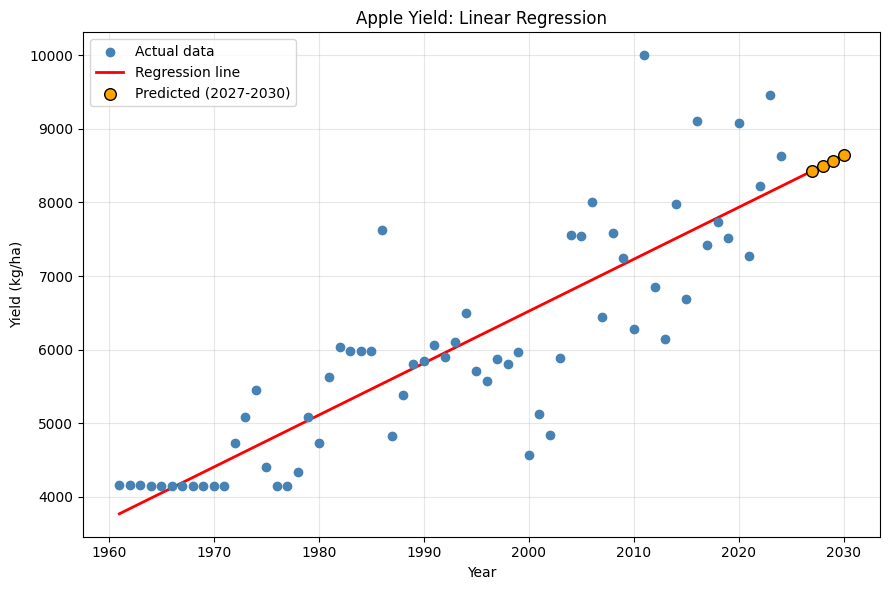

In [7]:
data = load_data(CSV_PATH)

if data.empty:
    print("No data found!")

else:
    years = data["year"].to_numpy()
    yields = data["yield"].to_numpy()

    # Train Linear Regression
    slope, intercept = train_linear_regression(years, yields)

    # Predictions on historical data
    predicted_yields = predict(slope, intercept, years)

    # Calculate evaluation metrics
    mse = calculate_mse(yields, predicted_yields)
    rmse = calculate_rmse(yields, predicted_yields)
    mae = calculate_mae(yields, predicted_yields)
    r2 = calculate_r2(yields, predicted_yields)

    # Display model parameters
    print(f"Slope     : {slope:.4f}")
    print(f"Intercept : {intercept:.4f}")

    # Display evaluation metrics
    print("\n----- Model Evaluation -----")
    print(f"MSE       : {mse:.4f}")
    print(f"RMSE      : {rmse:.4f}")
    print(f"MAE       : {mae:.4f}")
    print(f"R² Score  : {r2:.4f}")

    # -------------------------------
    # Future Predictions
    # -------------------------------

    predict_years = np.arange(2027, 2031)
    predict_yields = predict(slope, intercept, predict_years)

    print("\n----- Predicted Yield -----")

    for y, p in zip(predict_years, predict_yields):
        print(f"{y} -> {p:.2f} kg/ha")

    # -------------------------------
    # Plot
    # -------------------------------

    plt.figure(figsize=(9, 6))

    plt.scatter(
        years,
        yields,
        color="steelblue",
        label="Actual data",
        zorder=3
    )

    line_years = np.arange(
        years.min(),
        predict_years.max() + 1
    )

    line_yields = predict(
        slope,
        intercept,
        line_years
    )

    plt.plot(
        line_years,
        line_yields,
        color="red",
        linewidth=2,
        label="Regression line"
    )

    plt.scatter(
        predict_years,
        predict_yields,
        color="orange",
        edgecolor="black",
        s=70,
        label="Predicted (2027-2030)",
        zorder=4
    )

    plt.title("Apple Yield: Linear Regression")
    plt.xlabel("Year")
    plt.ylabel("Yield (kg/ha)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig("regression_plot.png", dpi=150)

    print("\nGraph saved to regression_plot.png")

    plt.show()